In [1]:
# OSNet-AIN 크로스 도메인 실험
# 논문: Learning Generalisable Omni-Scale Representations for Person Re-Identification
# IEEE TPAMI 2021

import torchreid
import torch

print(f"torchreid 버전: {torchreid.__version__}")
print(f"PyTorch 버전: {torch.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")

torchreid 버전: 1.4.0
PyTorch 버전: 2.5.1+cu121
GPU 사용 가능: True


In [5]:
# 데이터셋 로딩
# Market-1501에서 학습된 모델을 Duke에서 테스트 (크로스 도메인)
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')

datamanager = torchreid.data.ImageDataManager(
    root='/home/ubuntu/datasets',
    sources='market1501',         # 학습 데이터셋
    targets='dukemtmcreid',        # 테스트 데이터셋 (크로스 도메인!)
    height=256,
    width=128,
    batch_size_train=32,
    batch_size_test=32,
    transforms=['random_flip', 'random_crop']
)

Building train transforms ...
+ resize to 256x128
+ random flip
+ random crop (enlarge to 288x144 and crop 256x128)
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
Building test transforms ...
+ resize to 256x128
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
=> Loading train (source) dataset
=> Loaded Market1501
  ----------------------------------------
  subset   | # ids | # images | # cameras
  ----------------------------------------
  train    |   751 |    12936 |         6
  query    |   750 |     3368 |         6
  gallery  |   751 |    15913 |         6
  ----------------------------------------
=> Loading test (target) dataset
=> Loaded DukeMTMCreID
  ----------------------------------------
  subset   | # ids | # images | # cameras
  ----------------------------------------
  train    |   702 |    16522 |         8
  query    |   702 |     2228 |         8
  g

In [6]:
# OSNet-AIN 모델 로딩 (Market-1501에서 학습된 가중치)
model = torchreid.models.build_model(
    name='osnet_ain_x1_0',
    num_classes=751,
    pretrained=False
)

torchreid.utils.load_pretrained_weights(
    model,
    '/home/ubuntu/model/osnet_ain_x1_0_market1501_256x128_amsgrad_ep100_lr0.0015_coslr_b64_fb10_softmax_labsmth_flip_jitter.pth'
)

model = model.cuda()
print("OSNet-AIN 모델 로딩 완료!")

Successfully loaded pretrained weights from "/home/ubuntu/model/osnet_ain_x1_0_market1501_256x128_amsgrad_ep100_lr0.0015_coslr_b64_fb10_softmax_labsmth_flip_jitter.pth"
OSNet-AIN 모델 로딩 완료!


/home/ubuntu/deep-person-reid/torchreid/utils/torchtools.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fpath, map_location=map_location)


In [7]:
# 크로스 도메인 mAP 측정
engine = torchreid.engine.ImageSoftmaxEngine(
    datamanager,
    model,
    optimizer=torchreid.optim.build_optimizer(model, optim='adam', lr=0.0003)
)

engine.run(
    test_only=True,
    visrank=False
)

##### Evaluating dukemtmcreid (target) #####
Extracting features from query set ...
Done, obtained 2228-by-512 matrix
Extracting features from gallery set ...
Done, obtained 14588-by-512 matrix
Speed: 0.0088 sec/batch
Computing distance matrix with metric=euclidean ...
Computing CMC and mAP ...
** Results **
mAP: 31.1%
CMC curve
Rank-1  : 53.5%
Rank-5  : 67.9%
Rank-10 : 73.5%
Rank-20 : 77.5%


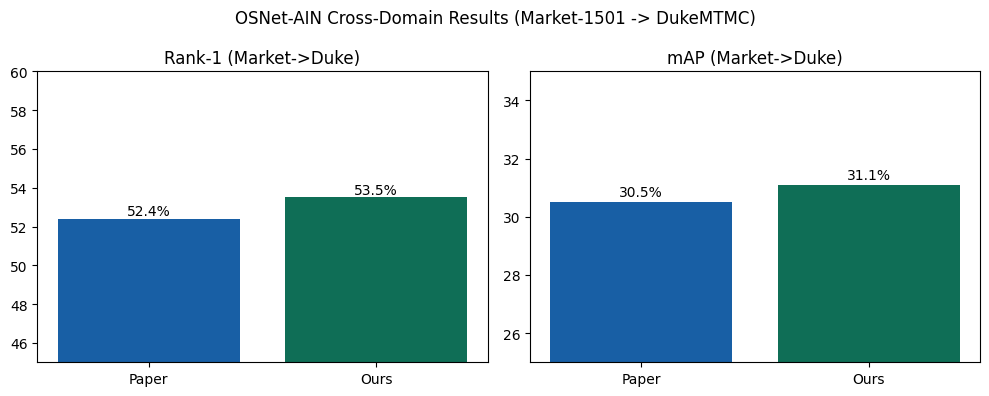

In [8]:
import matplotlib.pyplot as plt

# Paper vs Implementation
methods = ['Paper', 'Ours']
rank1 = [52.4, 53.5]
mAP_values = [30.5, 31.1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(methods, rank1, color=['#185FA5', '#0F6E56'])
ax1.set_title('Rank-1 (Market->Duke)')
ax1.set_ylim(45, 60)
for i, v in enumerate(rank1):
    ax1.text(i, v+0.2, f'{v}%', ha='center')

ax2.bar(methods, mAP_values, color=['#185FA5', '#0F6E56'])
ax2.set_title('mAP (Market->Duke)')
ax2.set_ylim(25, 35)
for i, v in enumerate(mAP_values):
    ax2.text(i, v+0.2, f'{v}%', ha='center')

plt.suptitle('OSNet-AIN Cross-Domain Results (Market-1501 -> DukeMTMC)')
plt.tight_layout()
plt.savefig('osnet_ain_results.png')
plt.show()